# Week 6 — Day 3: Backpropagation, Gradient Descent & Optimizers

**Project:** Stroke-Risk Prediction (capstone)
**Milestone:** Mentor Code & Notebook Review (mid-sprint pull request)

---

## Objective

Describe the four-step training loop of a neural network, explain gradient descent and the role of the learning rate, and explain backpropagation conceptually along with common optimizers, epochs, and batches.


## Lesson Content

### 3.1 — The Training Loop in One Picture

Training a neural network is a loop repeated over the data:

1. **Forward pass** — make a prediction (Day 2)
2. **Compute the loss** — measure how wrong the prediction was (Day 2)
3. **Backpropagation** — find how much each weight contributed to that loss
4. **Update the weights** — nudge them to reduce the loss

Repeat thousands of times, and the random initial weights gradually become accurate ones.

### 3.2 — Gradient Descent

Gradient descent is the update step. The gradient points in the direction of **steepest increase** in the loss for each weight; gradient descent moves each weight in the **opposite** direction — downhill — to reduce the loss.

**Intuition:** you're standing on a foggy hillside (the loss surface) and take small steps in the steepest downhill direction until you reach a valley (minimum loss).

### 3.3 — The Learning Rate

The learning rate controls the step size in gradient descent — the single most important hyperparameter in deep learning.

| Learning Rate | Effect |
|---|---|
| Too high | Overshoots the minimum; loss bounces or diverges |
| Too low | Trains very slowly; may get stuck |
| Just right | Steady, efficient decrease in loss |

### 3.4 — Backpropagation

Backpropagation is the algorithm that computes gradients efficiently. It works **backward** from the loss through the network, using the **chain rule** of calculus to determine exactly how much each weight contributed to the error — "assigning blame" to each weight. Frameworks compute it automatically (TensorFlow's `GradientTape`, PyTorch's `autograd`); understanding the concept is what matters here, not a by-hand implementation.

### 3.5 — Optimizers, Epochs, and Batches

| Term | Meaning |
|---|---|
| Optimizer | The algorithm that applies gradient descent; **Adam** is the strong default |
| Epoch | One full pass through the entire training dataset |
| Batch | A subset of data processed before each weight update (e.g. 32 samples) |
| SGD vs. Adam | SGD is basic gradient descent; Adam adapts the step size per weight |

**Practical rule:** use Adam as a reliable default, start with a learning rate around **0.001**, and adjust only if the loss curve misbehaves.


---

## Hands-On Lab: Understanding Training + Mentor Review

1. Draw/describe the four-step training loop in a Markdown cell for the project notebook.
2. Experiment with a tiny network at three learning rates (too high, too low, good) and plot the loss curves.
3. Explain, in your own words, what backpropagation computes and why the chain rule is involved.

**Mentor milestone:** notebook and code submitted via GitHub pull request for mid-sprint mentor review today.

**Tools:** NumPy, Matplotlib, Jupyter/Colab


### Step 1: The Four-Step Training Loop

```
   ┌──────────────────────────────────────────────────────────┐
   │                                                            │
   ▼                                                            │
FORWARD PASS  →  COMPUTE LOSS  →  BACKPROPAGATION  →  UPDATE WEIGHTS
(predict)        (how wrong?)     (assign blame,       (gradient descent,
                                    chain rule)           step downhill)
   │                                                            │
   └──────────────── repeat for every batch, every epoch ───────┘
```

1. **Forward pass** — data flows through the network to produce a prediction (`a2` in Day 2's example).
2. **Compute the loss** — compare the prediction to the true label (binary cross-entropy, Day 2).
3. **Backpropagation** — the chain rule works backward from the loss to compute the gradient of the loss with respect to every weight and bias (`∂Loss/∂W1`, `∂Loss/∂b1`, `∂Loss/∂W2`, `∂Loss/∂b2`).
4. **Update the weights** — gradient descent moves each weight a small step in the direction that reduces the loss: `W = W - learning_rate * gradient`.

This loop repeats for every batch of data, across every epoch, until the loss stops meaningfully decreasing.


### Imports

In [2]:
import numpy as np
import matplotlib.pyplot as plt


### Step 2: Learning Rate Experiment — Too High, Too Low, Just Right

Using simple 1D gradient descent on a toy loss surface `L(w) = (w - 3)**2` (minimum at `w = 3`), we can see the learning rate's effect directly without needing a full network. The gradient is `dL/dw = 2(w - 3)`.


In [3]:
def loss_fn(w):
    return (w - 3) ** 2

def grad_fn(w):
    return 2 * (w - 3)

def gradient_descent(start_w, lr, steps=30):
    w = start_w
    history = [w]
    for _ in range(steps):
        w = w - lr * grad_fn(w)
        history.append(w)
    return np.array(history)

start_w = -5.0
learning_rates = {
    "Too high (lr=1.05)": 1.05,
    "Too low (lr=0.01)": 0.01,
    "Just right (lr=0.3)": 0.3,
}

histories = {label: gradient_descent(start_w, lr) for label, lr in learning_rates.items()}


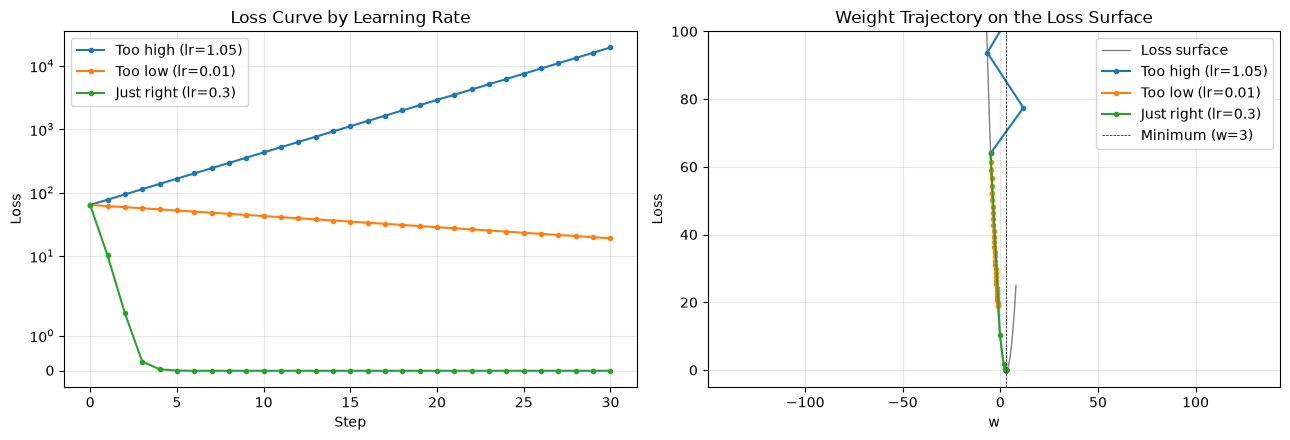

Too high (lr=1.05)     final w =  -136.5952   final loss = 19486.8249
Too low (lr=0.01)      final w =    -1.3639   final loss =    19.0434
Just right (lr=0.3)    final w =     3.0000   final loss =     0.0000


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: loss vs. step
for label, hist in histories.items():
    axes[0].plot(loss_fn(hist), marker="o", markersize=3, label=label)
axes[0].set_title("Loss Curve by Learning Rate")
axes[0].set_xlabel("Step")
axes[0].set_ylabel("Loss")
axes[0].set_yscale("symlog")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Right: weight trajectory over the loss surface
w_range = np.linspace(-8, 8, 200)
axes[1].plot(w_range, loss_fn(w_range), color="gray", lw=1, label="Loss surface")
for label, hist in histories.items():
    axes[1].plot(hist, loss_fn(hist), marker="o", markersize=3, label=label)
axes[1].axvline(3, color="black", lw=0.5, linestyle="--", label="Minimum (w=3)")
axes[1].set_title("Weight Trajectory on the Loss Surface")
axes[1].set_xlabel("w")
axes[1].set_ylabel("Loss")
axes[1].set_ylim(-5, 100)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

for label, hist in histories.items():
    print(f"{label:<22} final w = {hist[-1]:>10.4f}   final loss = {loss_fn(hist[-1]):>10.4f}")


**Observed behavior:**
- **Too high** (`lr=1.05`) — overshoots the minimum every step; the loss bounces or grows instead of settling, since `1.05 > 1.0` flips the update past the minimum and further away each time.
- **Too low** (`lr=0.01`) — moves toward `w=3` but very slowly; after 30 steps it hasn't converged, wasting compute.
- **Just right** (`lr=0.3`) — steady, efficient decrease, reaching very close to `w=3` within a handful of steps.

This is the same dynamic that plays out training the actual stroke-prediction network: the learning rate is the first hyperparameter to sanity-check if the training loss curve looks unstable (too high) or barely moves (too low).


### Step 3: What Backpropagation Computes, and Why the Chain Rule

**In my own words:** Backpropagation answers the question "how much did each individual weight contribute to the final loss?" A network is a chain of functions — input goes through layer 1, then layer 2, then the loss — so changing any one weight early in the network changes every computation downstream of it. The **chain rule** from calculus is exactly the tool for measuring how a change at one point in a chain of functions affects the output at the end: it lets you multiply local derivatives together, layer by layer, working backward from the loss to the first layer, without needing to re-derive the whole network's math by hand each time.

Concretely, for the Day 2 tiny network (`Input → Hidden(ReLU) → Output(Sigmoid) → BCE Loss`):
- Backprop first computes `∂Loss/∂a2` (how loss changes with the output prediction).
- Then it uses the chain rule to get `∂Loss/∂z2 = ∂Loss/∂a2 · ∂a2/∂z2` (pushing through the sigmoid).
- Then `∂Loss/∂W2` and `∂Loss/∂b2` follow directly from `∂Loss/∂z2`.
- The same gradient is pushed further backward, through `∂z2/∂a1` and the ReLU derivative, to get `∂Loss/∂W1` and `∂Loss/∂b1`.

Each of those gradients is exactly what gradient descent (Step 2 above) uses to update that weight: `W = W - learning_rate * gradient`. Frameworks like TensorFlow (`GradientTape`) automate this chain-rule bookkeeping — no one derives it by hand in practice — but the concept is what Day 4's Keras model relies on under the hood.


---

## Mentor Code & Notebook Review — Mid-Sprint Checkpoint

Today's milestone: submit the capstone project notebook (baseline model from Day 1, plus this notebook's concepts) as a GitHub pull request for structured mentor feedback on methodology and results, per the Sprint 1 cycle. Address any comments before Day 4's Keras implementation.
